# Assignment: Generative Modeling with Gaussian Mixture Models (GMM)
## Using GMM to Learn and Generate Handwritten Digit Images

**Course:** Intro to Machine Learning  
**Topic:** Clustering Part 2 - GMM as a Generative Model  

---

### Objective

In this assignment, you will:
1. Load and explore the MNIST handwritten digit dataset
2. Apply PCA to reduce dimensionality while preserving variance
3. Fit a Gaussian Mixture Model (GMM) to clusters of digit images
4. Use the trained GMM to **generate brand new synthetic digit images**
5. Experiment with per-digit GMM models for improved generation quality

### Background

GMM learns the underlying probability distribution of data by fitting a mixture of Gaussian (normal) distributions. Once trained, we can **sample** from that learned distribution to create new, synthetic data that follows the same patterns as the original. This is the core idea behind **generative models** - the same family of concepts that powers things like GANs and diffusion models.

### Grading
- Part 1 - Data Loading & Exploration: **10 marks**
- Part 2 - PCA Dimensionality Reduction: **15 marks**
- Part 3 - Fit GMM to All Digits: **20 marks**
- Part 4 - Generate New Digit Images: **20 marks**
- Part 5 - Per-Digit GMM Generation: **25 marks**
- Part 6 - Reflection Questions: **10 marks**

**Total: 100 marks**

---
## Part 0 - Setup (Provided)

Run the cells below to import the required libraries and define helper functions. **Do not modify these cells.**

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import math
import matplotlib as mpl

import warnings
warnings.filterwarnings("ignore")

In [21]:
# Helper function to display a single digit image
def showDigit(digit, label, size=28):
    some_digit_image = np.array(digit).reshape(size, size)
    plt.imshow(some_digit_image, cmap=mpl.cm.binary)
    plt.title(label)
    plt.axis("off")
    plt.show()

# Helper function to display multiple digit images in a grid
def showDigits(digits, labels, indexes, size=28, cols=6):
    pics = len(indexes)
    rows = math.ceil(pics / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6))
    plt.axis("off")
    for i in range(0, pics):
        n = indexes[i]
        some_digit = digits[n:n+1]
        some_digit_image = np.array(some_digit).reshape(size, size)
        ax = axes[i // cols, i % cols] if rows > 1 else axes[i % cols]
        ax.axis("off")
        ax.imshow(some_digit_image, cmap=mpl.cm.binary)
        ax.set_title('Ind: {} - Lbl: {}'.format(indexes[i], labels[n]))
    plt.tight_layout()
    plt.axis("off")
    plt.show()

---
## Part 1 - Load and Explore the Data (10 marks)

We will use the **MNIST** dataset, which contains 28x28 pixel grayscale images of handwritten digits (0-9). Each image is stored as a flat array of 784 pixel values.

### Task 1.1 - Load the Data (5 marks)
Load the MNIST dataset using `fetch_openml`. Use only the **first 15,000 samples** for speed. Store the features in `X` and the labels in `y`. Print the shapes of both.

In [22]:
# TODO: Load the MNIST dataset
# Hint: from sklearn.datasets import fetch_openml
#       mnist = fetch_openml('mnist_784', version=1)
#       Then slice the first 15000 rows for X and y

from sklearn.datasets import fetch_openml

# MY CODE HERE
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data[:15000]
y = mnist.target[:15000]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 784)
y shape: (15000,)


### Task 1.2 - Visualize Some Digits (5 marks)
Use the provided `showDigits()` function to display at least **10 sample images** from the dataset. Choose a variety of indexes so you see different digits.

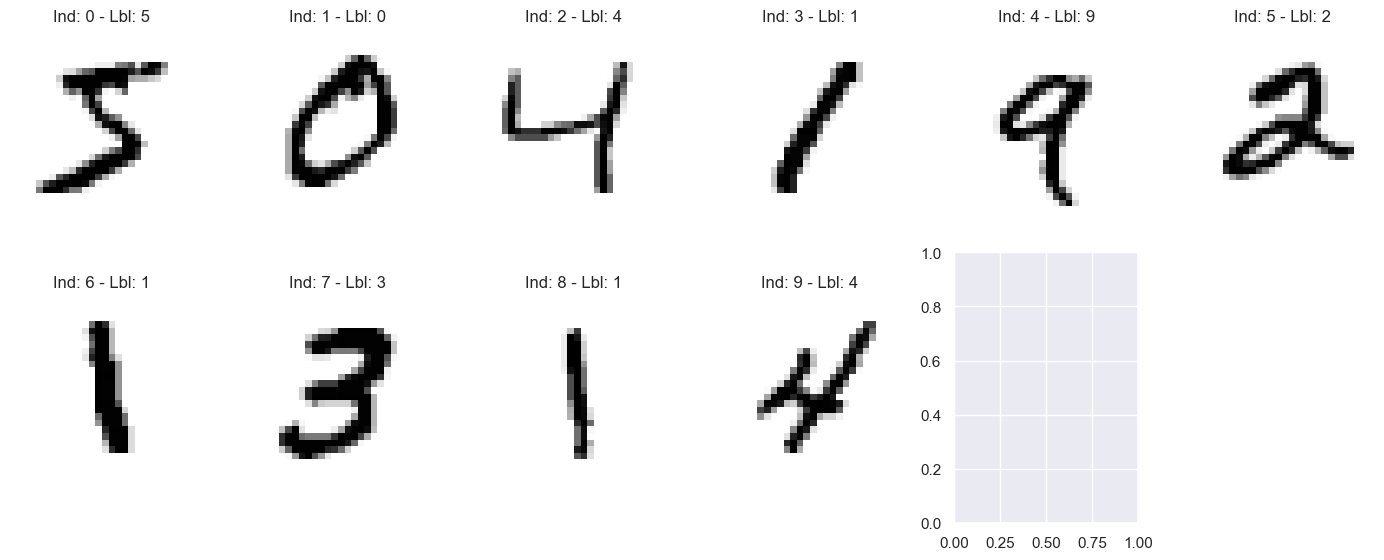

In [23]:
# TODO: Display at least 10 sample digit images using showDigits()
# Hint: showDigits(X, y, [list_of_indexes])

# YOUR CODE HERE
showDigits(X, y, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


---
## Part 2 - PCA Dimensionality Reduction (15 marks)

The raw MNIST data has 784 features (pixels). Fitting a GMM directly on 784 dimensions would be extremely slow and may not converge well. We use **PCA** to reduce the dimensionality while keeping most of the information.

### Task 2.1 - Apply PCA (10 marks)
Apply PCA to `X`, keeping **99% of the variance**. Store the transformed data in a variable called `data`. Print the new shape to see how many components PCA selected.

**Note:** The `whiten` parameter normalizes the variance of each component. You may set it to `False` for now.

In [24]:
# TODO: Apply PCA with 0.99 variance retained
# Hint: pca = PCA(0.99, whiten=False)
#       data = pca.fit_transform(X)

# YOUR CODE HERE
pca = PCA(0.99, whiten=False)
data = pca.fit_transform(X)

print("Original shape:", X.shape)
print("Reduced shape:", data.shape)
print("Number of components kept:", pca.n_components_)

Original shape: (15000, 784)
Reduced shape: (15000, 328)
Number of components kept: 328


### Task 2.2 - Interpret PCA (5 marks)
**Answer in a markdown cell below:**
- How many components did PCA keep?
- Why is PCA helpful before fitting a GMM? (Think about both speed and the curse of dimensionality.)

**ANSWER**

- PCA kept 328 components while preserving 99% of the variance.

- PCA is helpful because it reduces the number of features from 784 pixels to 328, which makes the model faster to train. It also helps remove noise and avoids the curse of dimensionality, where having too many features can make it harder for models like GMM to learn meaningful patterns.

---
## Part 3 - Fit a GMM to All Digits (20 marks)

Now we will fit a Gaussian Mixture Model to the PCA-reduced data. The GMM will learn the distribution of **all** digit images together.

### Task 3.1 - Create and Fit the GMM (10 marks)
Create a `GaussianMixture` model with:
- **300 components** (`n_components=300`)
- **`covariance_type='full'`** (allows each cluster to take any ellipsoidal shape)
- **`random_state=0`** (for reproducibility)

Fit it on the `data` (PCA-transformed). Print whether the model converged.

In [25]:
# TODO: Create and fit a GaussianMixture model
# Hint: gmm = GaussianMixture(300, covariance_type='full', random_state=0)
#       gmm.fit(data)

# YOUR CODE HERE
gmm = GaussianMixture(300, covariance_type='full', random_state=0)
gmm.fit(data)


print("Model converged:", gmm.converged_)

Model converged: True


### Task 3.2 - Why 300 Components? (10 marks)

**Answer in a markdown cell below:**
- Why might we use 300 components even though there are only 10 different digits (0-9)?
- What does each component represent in this context?
- How could you use AIC or BIC to choose the number of components? (You do not need to run AIC/BIC - just explain the concept.)

**ANSWER:**

- Why 300 components:

Even though there are only 10 digits, each digit can be written in many different ways, so the data has a lot of variation. Using 300 components allows the model to capture different styles, shapes, and patterns within each digit.

- What does each component represent in this context:

Each component represents a small pattern or variation in the data, not just a single digit. For example, different ways of writing “3” could be captured by different components.

- How could you use AIC or BIC to choose the number of components:

AIC and BIC are methods used to compare models with different numbers of components. They balance model fit and complexity, and the model with the lowest AIC or BIC score is usually the best choice.

---
## Part 4 - Generate New Digit Images (20 marks)

This is where the magic happens. The GMM has learned the distribution of digit images. We can now **sample** from it to create brand new, never-before-seen digit images.

### Task 4.1 - Sample from the GMM (10 marks)
Use the `.sample()` method to generate **10 new samples** from the fitted GMM. Then use `pca.inverse_transform()` to convert them back to 784-dimensional pixel space so they can be displayed as images.

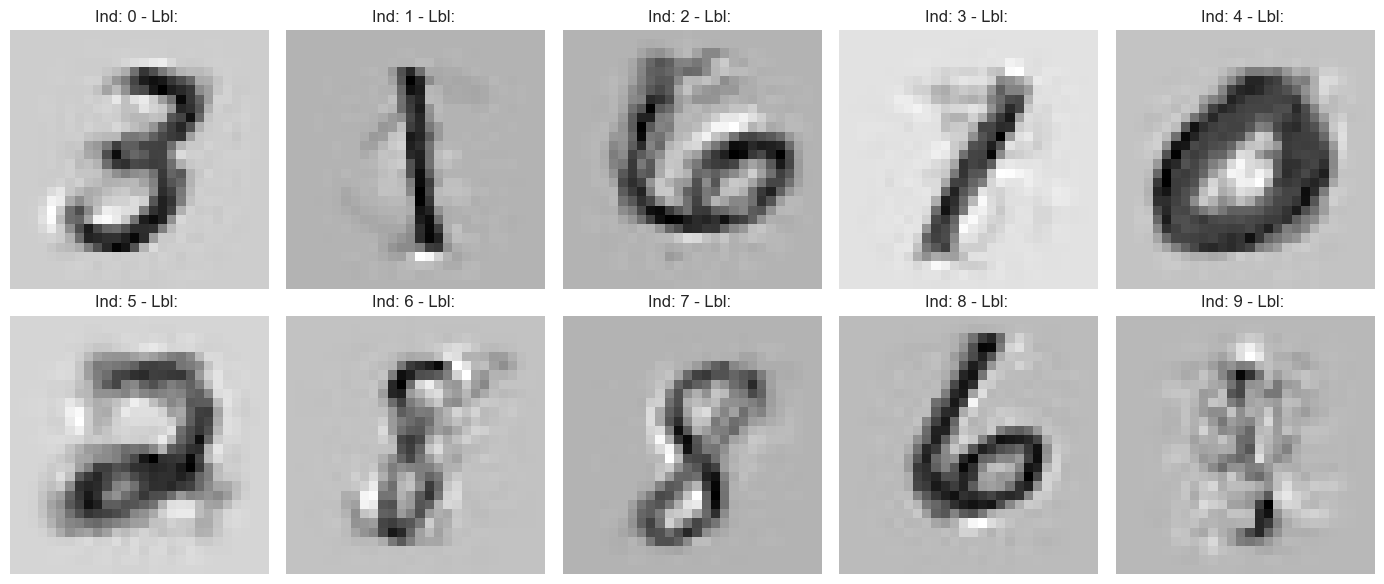

In [30]:
# TODO: Generate 10 new digit samples from the GMM
# Step 1: data_new = gmm.sample(10) - this returns a tuple, take the first element [0]
# Step 2: Use pca.inverse_transform() to get back to pixel space
# Step 3: Display using showDigits()

# Step 1: Sample from the GMM
data_new = gmm.sample(10)
data_new = data_new[0]

# Step 2: Inverse transform back to pixel space
digits_new = pca.inverse_transform(data_new)

# Step 3: Display generated digits
showDigits(
    digits=digits_new,
    labels=[""]*10,
    indexes=list(range(10)),
    size=28,
    cols=5
)

### Task 4.2 - Analyze the Results (10 marks)
**Answer in a markdown cell below:**
- Do the generated images look like real handwritten digits?
- Are some clearer than others? Why might that be?
- Why might the images appear blurry or noisy? (Think about what the GMM is doing - it learned ALL digits at once.)

**ANSWER:**

- Some of the generated images look like real handwritten digits, but others are blurry or   unclear.

- The clearer ones likely come from components that strongly represent a specific digit pattern, while the blurry ones happen because the model is trying to represent all digits at once.

- Since the GMM was trained on all digits together, it sometimes mixes features from different digits, which leads to noisy or unclear images.

---
## Part 5 - Per-Digit GMM Generation (25 marks)

The GMM above tried to model all 10 digits simultaneously. We can do better by training **separate GMMs for individual digits**. This way, each model only needs to learn the patterns of one specific digit.

### Task 5.1 - Train a GMM on a Single Digit (10 marks)
Pick a digit (0-9) and filter the PCA-transformed data to only include samples of that digit. Then fit a new GMM (300 components, full covariance) on just that subset. Generate and display 10 new samples.

**Hint:** You can filter with `data[y.astype(int) == YOUR_DIGIT]`

Number of samples for digit 9: 1503


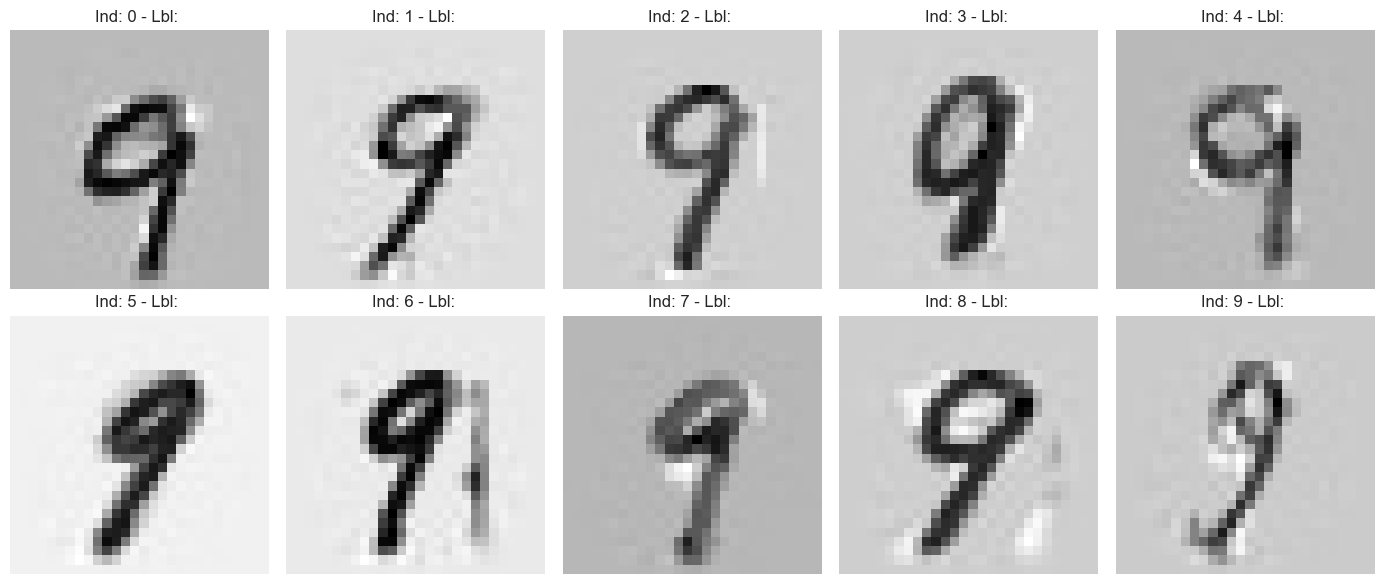

In [27]:
# TODO: Choose a digit, filter data, fit GMM, generate and display new images
# Pick a digit 0-9
DIGIT_TO_GENERATE = 9

# Step 1: Filter PCA data for this digit
digit_data = data[y.astype(int) == DIGIT_TO_GENERATE]
print(f"Number of samples for digit {DIGIT_TO_GENERATE}:", digit_data.shape[0])

# Step 2: Fit GMM
gmm_single = GaussianMixture(n_components=300, covariance_type='full', random_state=0)
gmm_single.fit(digit_data)

# Step 3: Generate 10 new samples
data_new_single, _ = gmm_single.sample(10) # sample() returns (samples, labels)

# Step 4: Inverse transform to pixel space
new_digits_single = pca.inverse_transform(data_new_single)  # make sure this variable matches

# Step 5: Display the 10 new digits
showDigits(
    digits=new_digits_single,
    labels=[""]*10,           # empty labels
    indexes=list(range(len(new_digits_single))),  # safest: match number of generated samples
    size=28,
    cols=5
)

### Task 5.2 - Generate a Second Digit (5 marks)
Repeat the process above for a **different** digit. Display the generated samples.

Number of samples for digit 7: 1593


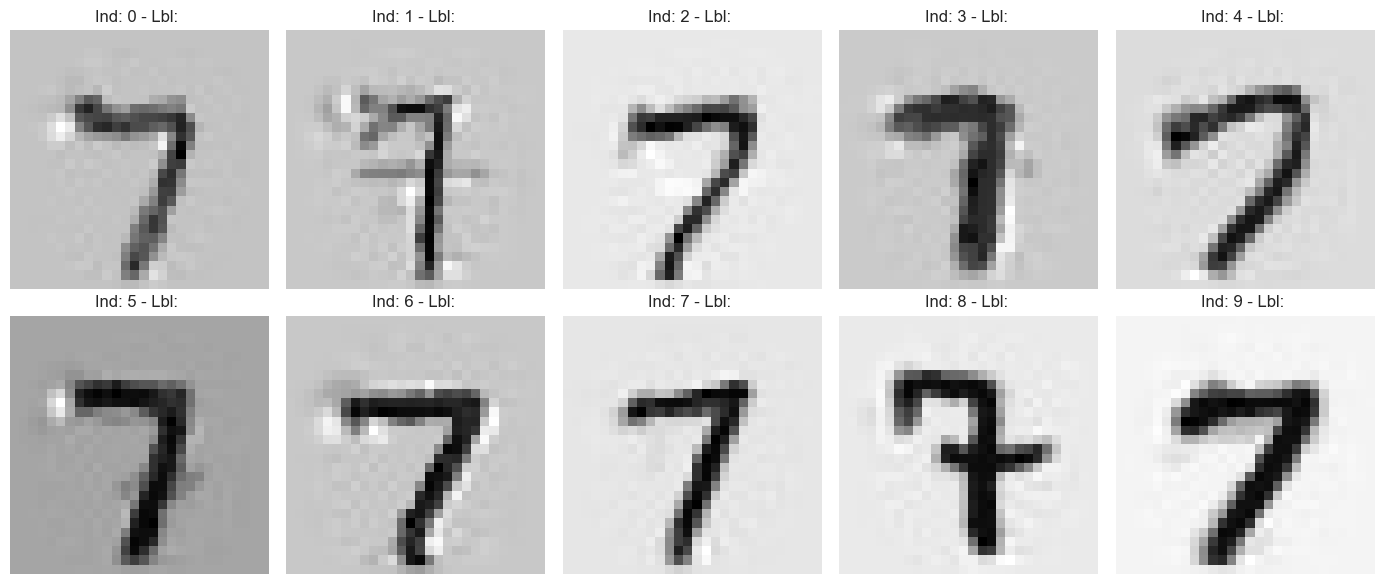

In [28]:
# TODO: Repeat for a different digit

# Pick a digit 0-9
DIGIT_TO_GENERATE_2 = 7 # Pick a DIFFERENT digit

# Step 1: Filter PCA data for this digit
digit_data = data[y.astype(int) == DIGIT_TO_GENERATE_2]
print(f"Number of samples for digit {DIGIT_TO_GENERATE_2}:", digit_data.shape[0])

# Step 2: Fit GMM
gmm_single = GaussianMixture(n_components=300, covariance_type='full', random_state=0)
gmm_single.fit(digit_data)

# Step 3: Generate 10 new samples
data_new_single, _ = gmm_single.sample(10) # sample() returns (samples, labels)

# Step 4: Inverse transform to pixel space
new_digits_single = pca.inverse_transform(data_new_single)  # make sure this variable matches

# Step 5: Display the 10 new digits
showDigits(
    digits=new_digits_single,
    labels=[""]*10,           # empty labels
    indexes=list(range(len(new_digits_single))),  # safest: match number of generated samples
    size=28,
    cols=5
)



### Task 5.3 - Compare Quality (10 marks)
**Answer in a markdown cell below:**
- Compare the images generated from the per-digit GMM (Part 5) to those from the all-digit GMM (Part 4). Which are clearer? Why?
- What is the trade-off of training 10 separate models vs. one combined model?
- In real-world applications, how is this idea of learning data distributions and generating new samples used? Give at least one example beyond handwritten digits.

**ANSWER:**

- The images generated from the per-digit GMM are generally clearer than those from the all-digit GMM. This is because each model is focused on learning only one digit, so it captures more specific patterns instead of mixing multiple digits together.

- The trade-off is that training 10 separate models takes more time and resources compared to training one model on all digits. However, it gives better quality results.

- In real-world applications, this idea is used in areas like image generation, speech synthesis, and data simulation. For example, models can generate realistic human faces or create synthetic data for training other machine learning systems.

---
## Part 6 - Reflection Questions (10 marks)

Answer the following questions in the markdown cell below. Each is worth 5 marks.

1. **Generative vs. Discriminative:** In your own words, explain the difference between a *generative* model (like GMM) and a *discriminative* model (like logistic regression). What does each type of model learn?

2. **Role of PCA:** What would happen if we skipped the PCA step and fit the GMM directly on the 784-dimensional pixel data? Consider both practical issues (speed, convergence) and conceptual issues (noise, meaningful features).

**ANSWER:**

#### Generative vs Discriminative

- Generative (GMM):

A generative model like GMM learns the overall distribution of the data and can generate new samples from it. It tries to understand how the data is formed.

- Discriminative:

A discriminative model, like logistic regression, focuses on learning the boundary between classes and is mainly used for prediction. It does not generate new data.

#### Role of PCA

- If we skipped PCA and trained the GMM directly on the 784 features, the model would be very slow and might not converge properly. High-dimensional data also contains a lot of noise, which can make it harder for the model to learn meaningful patterns.

- PCA reduces the number of features while keeping the important information, making the model faster and more stable.

---
### Submission

- Save this notebook with all cells executed (Kernel -> Restart & Run All)
- Ensure all outputs (plots, printed shapes) are visible
- Submit the `.ipynb` file

**Good luck!**